In [1]:
import pandas as pd

df = pd.read_csv("train.csv", encoding="latin1")

print(df.head())

print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [2]:
print(df.info())

print("\nMissing Values:\n")

print(df.isnull().sum())

print("\nStatistics:\n")

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [3]:
print(df["Category"].value_counts())

print(df["Region"].value_counts())

print(df["Segment"].value_counts())

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64


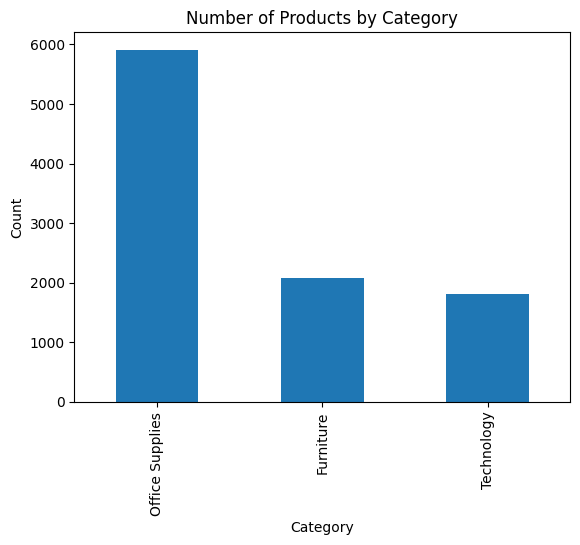

In [4]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")

plt.title("Number of Products by Category")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

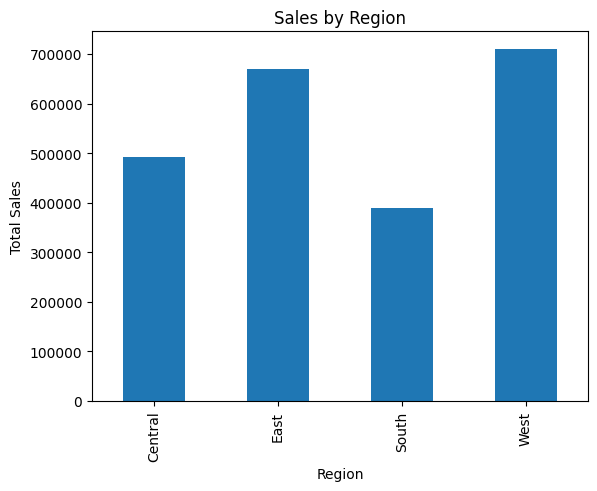

In [5]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Total Sales")

plt.show()

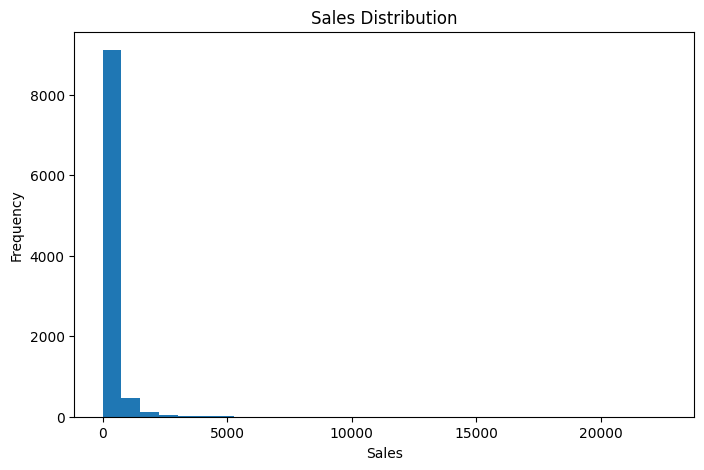

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

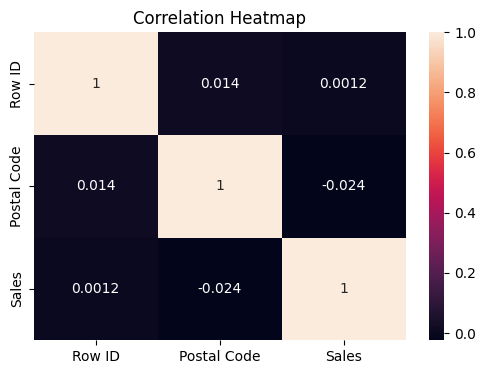

In [7]:
import seaborn as sns

numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

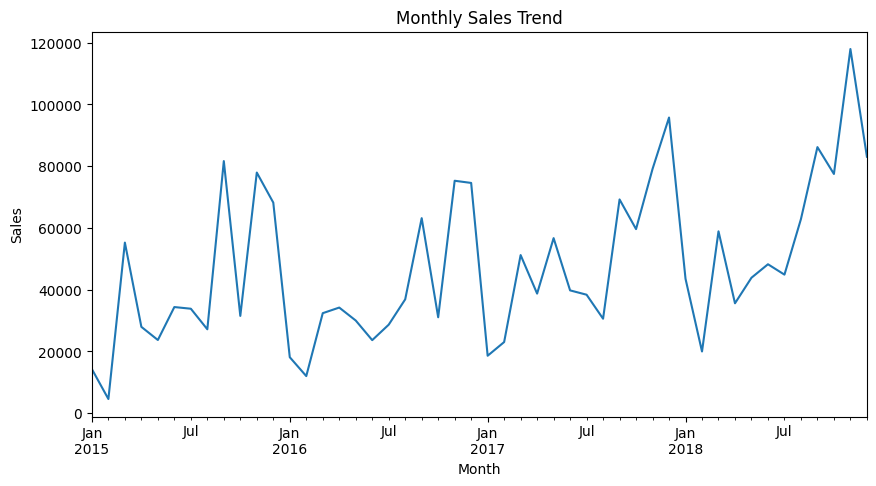

In [10]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [11]:
import sqlite3

conn = sqlite3.connect("sales.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully")

Database created successfully


In [12]:
query = """
SELECT Region,
SUM(Sales) as TotalSales
FROM sales
GROUP BY Region
ORDER BY TotalSales DESC
"""

result = pd.read_sql(query, conn)

print(result)

    Region   TotalSales
0     West  710219.6845
1     East  669518.7260
2  Central  492646.9132
3    South  389151.4590


In [13]:
query = """
SELECT [Product Name],
SUM(Sales) as TotalSales
FROM sales
GROUP BY [Product Name]
ORDER BY TotalSales DESC
LIMIT 5
"""

result = pd.read_sql(query, conn)

print(result)

                                        Product Name  TotalSales
0              Canon imageCLASS 2200 Advanced Copier   61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...   27453.384
2  Cisco TelePresence System EX90 Videoconferenci...   22638.480
3       HON 5400 Series Task Chairs for Big and Tall   21870.576
4         GBC DocuBind TL300 Electric Binding System   19823.479


In [14]:
query = """
SELECT Category,
SUM(Sales) as TotalSales
FROM sales
GROUP BY Category
"""

result = pd.read_sql(query, conn)

print(result)

          Category   TotalSales
0        Furniture  728658.5757
1  Office Supplies  705422.3340
2       Technology  827455.8730


In [15]:
query = """
SELECT State,
SUM(Sales) as TotalSales
FROM sales
GROUP BY State
ORDER BY TotalSales DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

print(result)

          State   TotalSales
0    California  446306.4635
1      New York  306361.1470
2         Texas  168572.5322
3    Washington  135206.8500
4  Pennsylvania  116276.6500
5       Florida   88436.5320
6      Illinois   79236.5170
7      Michigan   76136.0740
8          Ohio   75130.3500
9      Virginia   70636.7200


In [16]:
query = """
SELECT Segment,
SUM(Sales) as TotalSales
FROM sales
GROUP BY Segment
ORDER BY TotalSales DESC
"""

result = pd.read_sql(query, conn)

print(result)

       Segment    TotalSales
0     Consumer  1.148061e+06
1    Corporate  6.884941e+05
2  Home Office  4.249822e+05


In [17]:
query = """
SELECT COUNT(DISTINCT [Customer ID]) as TotalCustomers
FROM sales
"""

result = pd.read_sql(query, conn)

print(result)

   TotalCustomers
0             793


In [18]:
query = """
SELECT [Ship Mode],
COUNT(*) as Orders
FROM sales
GROUP BY [Ship Mode]
ORDER BY Orders DESC
"""

result = pd.read_sql(query, conn)

print(result)

        Ship Mode  Orders
0  Standard Class    5859
1    Second Class    1902
2     First Class    1501
3        Same Day     538


In [19]:
query = """
SELECT [Sub-Category],
SUM(Sales) as TotalSales
FROM sales
GROUP BY [Sub-Category]
ORDER BY TotalSales DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

print(result)

  Sub-Category   TotalSales
0       Phones  327782.4480
1       Chairs  322822.7310
2      Storage  219343.3920
3       Tables  202810.6280
4      Binders  200028.7850
5     Machines  189238.6310
6  Accessories  164186.7000
7      Copiers  146248.0940
8    Bookcases  113813.1987
9   Appliances  104618.4030


Key Findings:

• West region generated the highest revenue (~710K)

• South region generated the lowest revenue (~389K)

• Technology category produced the highest sales revenue

• Office Supplies had the largest number of products

• Consumer segment contributed the highest number of transactions

• A few products contribute disproportionately to revenue generation

• Customer purchases are concentrated in certain states and regions

In [ ]:
# Scatter Plot: Order Count vs Total Sales by Sub-Category (Multivariate)
import matplotlib.pyplot as plt
import seaborn as sns

sub_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
sub_sales['Order Count'] = df.groupby('Sub-Category')['Order ID'].count().values

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=sub_sales,
    x='Order Count',
    y='Sales',
    hue='Sub-Category',
    s=120,
    legend=False
)
for _, row in sub_sales.iterrows():
    plt.text(row['Order Count'] + 0.5, row['Sales'], row['Sub-Category'], fontsize=8)
plt.title('Scatter Plot: Order Count vs Total Sales by Sub-Category')
plt.xlabel('Number of Orders')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
# Pair Plot: Multivariate Analysis (Sales vs Encoded Categorical Variables)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pair_df = df[['Sales', 'Category', 'Region', 'Segment']].copy()
le = LabelEncoder()
pair_df['Category_enc'] = le.fit_transform(pair_df['Category'])
pair_df['Region_enc']   = le.fit_transform(pair_df['Region'])
pair_df['Segment_enc']  = le.fit_transform(pair_df['Segment'])

sns.pairplot(
    pair_df[['Sales', 'Category_enc', 'Region_enc', 'Segment_enc']],
    diag_kind='kde',
    plot_kws={'alpha': 0.4}
)
plt.suptitle('Pair Plot: Sales vs Encoded Categorical Variables', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# SQL Multi-Table JOIN
# Split data into two tables: orders + order_items, then JOIN
import sqlite3
import pandas as pd

conn2 = sqlite3.connect(':memory:')

# Table 1: orders (order-level info)
orders_df = df[['Order ID', 'Customer ID', 'Customer Name', 'Segment',
                'Region', 'State', 'Ship Mode', 'Order Date']].drop_duplicates(subset=['Order ID'])
orders_df.to_sql('orders', conn2, index=False, if_exists='replace')

# Table 2: order_items (line-item info)
items_df = df[['Order ID', 'Product ID', 'Product Name', 'Category', 'Sub-Category', 'Sales']]
items_df.to_sql('order_items', conn2, index=False, if_exists='replace')

# JOIN Query: Revenue breakdown by Region & Segment
join_query = """
SELECT
    o.Region,
    o.Segment,
    COUNT(o.[Order ID]) AS TotalOrders,
    ROUND(SUM(i.Sales), 2) AS TotalSales,
    ROUND(AVG(i.Sales), 2) AS AvgSalePerItem
FROM orders o
JOIN order_items i ON o.[Order ID] = i.[Order ID]
GROUP BY o.Region, o.Segment
ORDER BY TotalSales DESC
"""

join_result = pd.read_sql(join_query, conn2)
print(join_result.to_string(index=False))
conn2.close()

## Dashboard KPI Mockup

> A static mock-up of the most important KPIs to track for a Sales BI Dashboard.

---

### KPI 1 — Total Revenue
| Metric | Value |
|--------|-------|
| Total Sales | ~$2.3M |
| MoM Growth | ~+5% (from monthly trend) |
| Top Region | West (~$710K) |

---

### KPI 2 — Orders & Customers
| Metric | Value |
|--------|-------|
| Total Unique Orders | ~4,922 |
| Total Unique Customers | 793 |
| Avg Order Value | ~$230.77 |

---

### KPI 3 — Category Performance
| Category | Performance |
|----------|-------------|
| Technology | Highest Revenue |
| Furniture | Medium Revenue |
| Office Supplies | Highest Volume, Lowest per order |

---

### KPI 4 — Customer Segment Split
| Segment | Share |
|---------|-------|
| Consumer | 52% |
| Corporate | 30% |
| Home Office | 18% |

---

### KPI 5 — Shipping Efficiency
| Ship Mode | Order Share |
|-----------|-------------|
| Standard Class | ~60% |
| Second Class | ~19% |
| First Class | ~15% |
| Same Day | ~6% |

---

### Proposed Dashboard Layout
```
+--------------------+-------------------+------------------+
| Total Revenue      | Total Orders      | Total Customers  |
| ~$2.3M             | 4,922             | 793              |
+--------------------+-------------------+------------------+
| Monthly Sales Trend (Line Chart)                          |
+-----------------------------------------------------------+
| Sales by Region    | Sales by Category | Segment Split    |
| (Bar Chart)        | (Bar Chart)       | (Pie Chart)      |
+--------------------+-------------------+------------------+
| Top 10 Products by Revenue (Horizontal Bar)               |
+-----------------------------------------------------------+
| Ship Mode Distribution | Sub-Category Sales Scatter       |
+------------------------+----------------------------------+
```


In [20]:
total_sales = df["Sales"].sum()

total_orders = df["Order ID"].nunique()

top_region = df.groupby("Region")["Sales"].sum().idxmax()

top_category = df.groupby("Category")["Sales"].sum().idxmax()

top_product = df.groupby("Product Name")["Sales"].sum().idxmax()

total_customers = df["Customer ID"].nunique()

print("Total Sales:", total_sales)

print("Total Orders:", total_orders)

print("Top Region:", top_region)

print("Top Category:", top_category)

print("Top Product:", top_product)

print("Total Customers:", total_customers)

Total Sales: 2261536.7827
Total Orders: 4922
Top Region: West
Top Category: Technology
Top Product: Canon imageCLASS 2200 Advanced Copier
Total Customers: 793
